# DriftGuard — Exploratory Data Analysis

This notebook examines the leakage-safe DriftGuard datasets created by
Notebook 05.

The analysis covers:

- Dataset and repository composition
- Training-label imbalance
- Weak-label confidence and provenance
- Configuration types and operations
- Structured parsing versus line fallback
- Security-rule distribution
- Common field paths and sensitive terms
- Value-length and field-depth characteristics
- Commit-level and temporal drift patterns
- Structural distribution shift between train, validation and test

Validation and test data are used only for descriptive structural analysis.
They are not used to fit models or tune thresholds.

In [1]:
import os
import sys
import json
import math
from pathlib import Path
from datetime import datetime, timezone
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


print("=" * 72)
print("DRIFTGUARD — EXPLORATORY DATA ANALYSIS")
print("=" * 72)

current_directory = Path.cwd().resolve()

if current_directory.name.lower() == "notebooks":
    PROJECT_ROOT = current_directory.parent
else:
    PROJECT_ROOT = current_directory

CLEAN_DATA_DIR = PROJECT_ROOT / "data" / "clean"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
EDA_OUTPUT_DIR = OUTPUTS_DIR / "eda"
EDA_FIGURES_DIR = EDA_OUTPUT_DIR / "figures"
EDA_TABLES_DIR = EDA_OUTPUT_DIR / "tables"
CONFIGS_DIR = PROJECT_ROOT / "configs"

EDA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
EDA_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
EDA_TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("Python version   :", sys.version.split()[0])
print("Python executable:", sys.executable)
print("Conda environment:", os.environ.get("CONDA_DEFAULT_ENV", "Not detected"))
print("Project root     :", PROJECT_ROOT)
print("EDA output       :", EDA_OUTPUT_DIR)

DRIFTGUARD — EXPLORATORY DATA ANALYSIS
Python version   : 3.11.15
Python executable: C:\Users\Lenovo\anaconda3\envs\driftguard\python.exe
Conda environment: driftguard
Project root     : C:\Users\Lenovo\Desktop\DriftGuard
EDA output       : C:\Users\Lenovo\Desktop\DriftGuard\outputs\eda


In [2]:
EDA_SETTINGS = {
    "random_seed": 42,
    "top_n_field_paths": 30,
    "top_n_sensitive_terms": 30,
    "top_n_rules": 20,
    "top_n_configuration_types": 20,
    "minimum_category_records": 10,
    "figure_dpi": 150,
}

eda_settings_path = (
    CONFIGS_DIR / "exploratory_data_analysis_settings.json"
)

with eda_settings_path.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        EDA_SETTINGS,
        file,
        indent=2,
    )

print(json.dumps(EDA_SETTINGS, indent=2))

{
  "random_seed": 42,
  "top_n_field_paths": 30,
  "top_n_sensitive_terms": 30,
  "top_n_rules": 20,
  "top_n_configuration_types": 20,
  "minimum_category_records": 10,
  "figure_dpi": 150
}


In [3]:
DATASET_PATHS = {
    "clean_manifest": (
        CLEAN_DATA_DIR
        / "clean_manifest_all_splits.csv.gz"
    ),
    "balanced_training": (
        CLEAN_DATA_DIR
        / "train_supervised_balanced.csv.gz"
    ),
    "model_training": (
        CLEAN_DATA_DIR
        / "train_temporal_model_train.csv.gz"
    ),
    "temporal_development": (
        CLEAN_DATA_DIR
        / "train_temporal_development.csv.gz"
    ),
    "validation_review": (
        CLEAN_DATA_DIR
        / "validation_review_only.csv.gz"
    ),
    "test_review": (
        CLEAN_DATA_DIR
        / "test_final_evaluation_only.csv.gz"
    ),
    "unlabeled_pool": (
        CLEAN_DATA_DIR
        / "unlabeled_annotation_pool.csv.gz"
    ),
}

missing_files = [
    str(path)
    for path in DATASET_PATHS.values()
    if not path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "Missing Notebook 05 outputs:\n"
        + "\n".join(missing_files)
    )

clean_manifest = pd.read_csv(
    DATASET_PATHS["clean_manifest"],
    compression="gzip",
    low_memory=False,
)

balanced_training = pd.read_csv(
    DATASET_PATHS["balanced_training"],
    compression="gzip",
    low_memory=False,
)

model_training = pd.read_csv(
    DATASET_PATHS["model_training"],
    compression="gzip",
    low_memory=False,
)

temporal_development = pd.read_csv(
    DATASET_PATHS["temporal_development"],
    compression="gzip",
    low_memory=False,
)

validation_review = pd.read_csv(
    DATASET_PATHS["validation_review"],
    compression="gzip",
    low_memory=False,
)

test_review = pd.read_csv(
    DATASET_PATHS["test_review"],
    compression="gzip",
    low_memory=False,
)

unlabeled_pool = pd.read_csv(
    DATASET_PATHS["unlabeled_pool"],
    compression="gzip",
    low_memory=False,
)

print("Datasets loaded successfully.")

Datasets loaded successfully.


In [4]:
dataset_inventory = pd.DataFrame(
    [
        {
            "dataset": "clean_manifest",
            "records": len(clean_manifest),
            "columns": len(clean_manifest.columns),
            "repositories": clean_manifest[
                "repository"
            ].nunique(),
            "commits": clean_manifest[
                "commit_hash"
            ].nunique(),
        },
        {
            "dataset": "balanced_training",
            "records": len(balanced_training),
            "columns": len(balanced_training.columns),
            "repositories": balanced_training[
                "repository"
            ].nunique(),
            "commits": balanced_training[
                "commit_hash"
            ].nunique(),
        },
        {
            "dataset": "model_training",
            "records": len(model_training),
            "columns": len(model_training.columns),
            "repositories": model_training[
                "repository"
            ].nunique(),
            "commits": model_training[
                "commit_hash"
            ].nunique(),
        },
        {
            "dataset": "temporal_development",
            "records": len(temporal_development),
            "columns": len(temporal_development.columns),
            "repositories": temporal_development[
                "repository"
            ].nunique(),
            "commits": temporal_development[
                "commit_hash"
            ].nunique(),
        },
        {
            "dataset": "validation_review",
            "records": len(validation_review),
            "columns": len(validation_review.columns),
            "repositories": validation_review[
                "repository"
            ].nunique(),
            "commits": validation_review[
                "commit_hash"
            ].nunique(),
        },
        {
            "dataset": "test_review",
            "records": len(test_review),
            "columns": len(test_review.columns),
            "repositories": test_review[
                "repository"
            ].nunique(),
            "commits": test_review[
                "commit_hash"
            ].nunique(),
        },
        {
            "dataset": "unlabeled_pool",
            "records": len(unlabeled_pool),
            "columns": len(unlabeled_pool.columns),
            "repositories": unlabeled_pool[
                "repository"
            ].nunique(),
            "commits": unlabeled_pool[
                "commit_hash"
            ].nunique(),
        },
    ]
)

display(dataset_inventory)

dataset_inventory.to_csv(
    EDA_TABLES_DIR / "dataset_inventory.csv",
    index=False,
)

,dataset,records,columns,repositories,commits
0,clean_manifest,219868,30,6,4428
1,balanced_training,9576,38,3,1324
2,model_training,7711,38,3,1058
3,temporal_development,1865,38,3,266
4,validation_review,7628,31,1,534
5,test_review,68749,31,2,1252
6,unlabeled_pool,26539,31,6,445


In [5]:
analysis_dataframes = [
    clean_manifest,
    balanced_training,
    model_training,
    temporal_development,
    validation_review,
    test_review,
    unlabeled_pool,
]

for dataframe in analysis_dataframes:
    dataframe["commit_author_datetime"] = pd.to_datetime(
        dataframe["commit_author_date"],
        errors="coerce",
        utc=True,
    )

    if "weak_label_confidence" in dataframe.columns:
        dataframe["weak_label_confidence"] = pd.to_numeric(
            dataframe["weak_label_confidence"],
            errors="coerce",
        )

    if "sample_weight" in dataframe.columns:
        dataframe["sample_weight"] = pd.to_numeric(
            dataframe["sample_weight"],
            errors="coerce",
        )

print("Analysis datatypes normalized.")

Analysis datatypes normalized.


In [6]:
split_repository_summary = (
    clean_manifest
    .groupby(
        [
            "dataset_split",
            "repository",
        ],
        as_index=False,
    )
    .agg(
        records=("diff_id", "count"),
        commits=("commit_hash", "nunique"),
        source_file_changes=(
            "source_record_id",
            "nunique",
        ),
        files=("file_path", "nunique"),
        field_paths=("field_path", "nunique"),
        configuration_types=(
            "configuration_type",
            "nunique",
        ),
    )
)

display(split_repository_summary)

split_repository_summary.to_csv(
    EDA_TABLES_DIR
    / "split_repository_summary.csv",
    index=False,
)

,dataset_split,repository,records,commits,source_file_changes,files,field_paths,configuration_types
0,test,ansible_examples,6139,195,715,299,1856,5
1,test,terraform_eks_blueprints,62610,1057,5223,1453,25202,8
2,train,kube_prometheus,76315,1216,4000,395,32577,7
3,train,microservices_demo,57045,1150,2774,178,16296,9
4,train,terraform_aws_vpc,10131,276,715,95,5212,3
5,validation,kubernetes_examples,7628,534,1449,609,1782,5


,dataset_split,records,percentage
0,train,143491,65.262339
1,test,68749,31.268306
2,validation,7628,3.469354


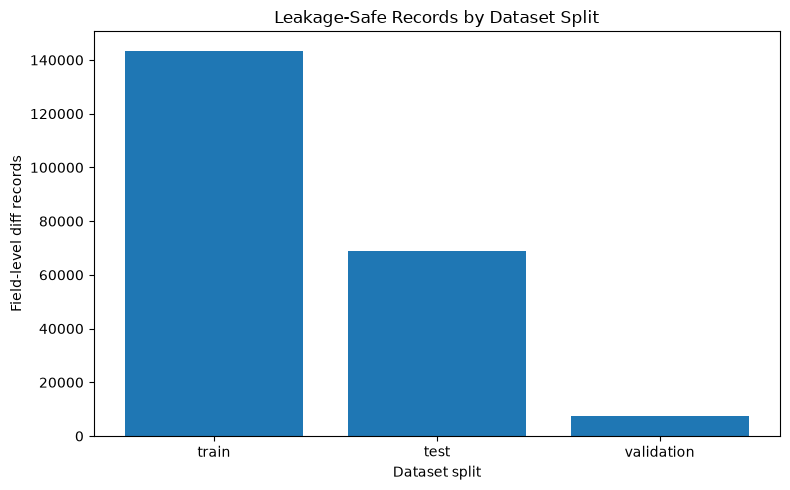

Saved: C:\Users\Lenovo\Desktop\DriftGuard\outputs\eda\figures\records_by_dataset_split.png


In [7]:
split_distribution = (
    clean_manifest[
        "dataset_split"
    ]
    .value_counts()
    .rename_axis("dataset_split")
    .reset_index(name="records")
)

split_distribution["percentage"] = (
    split_distribution["records"]
    / split_distribution["records"].sum()
    * 100
)

display(split_distribution)

plt.figure(figsize=(8, 5))

plt.bar(
    split_distribution["dataset_split"],
    split_distribution["records"],
)

plt.title("Leakage-Safe Records by Dataset Split")
plt.xlabel("Dataset split")
plt.ylabel("Field-level diff records")
plt.tight_layout()

split_figure_path = (
    EDA_FIGURES_DIR
    / "records_by_dataset_split.png"
)

plt.savefig(
    split_figure_path,
    dpi=EDA_SETTINGS["figure_dpi"],
    bbox_inches="tight",
)

plt.show()

print("Saved:", split_figure_path)

In [8]:
missingness_report = pd.DataFrame(
    {
        "column": clean_manifest.columns,
        "missing_records": [
            int(clean_manifest[column].isna().sum())
            for column in clean_manifest.columns
        ],
    }
)

missingness_report["missing_percentage"] = (
    missingness_report["missing_records"]
    / len(clean_manifest)
    * 100
)

missingness_report = missingness_report.sort_values(
    "missing_percentage",
    ascending=False,
)

display(missingness_report.head(25))

missingness_report.to_csv(
    EDA_TABLES_DIR / "missingness_report.csv",
    index=False,
)

,column,missing_records,missing_percentage
19,primary_rule_id,148247,67.425455
13,old_value,97355,44.278840
14,new_value,62731,28.531210
3,dataset_split,0,0.000000
2,repository,0,0.000000
0,diff_id,0,0.000000
5,commit_author_date,0,0.000000
6,commit_message,0,0.000000
8,configuration_type,0,0.000000
7,file_path,0,0.000000


In [9]:
training_class_distribution = (
    balanced_training[
        "training_target"
    ]
    .value_counts()
    .reindex(
        [
            "benign",
            "low",
            "medium",
            "high",
            "critical",
        ],
        fill_value=0,
    )
    .rename_axis("training_target")
    .reset_index(name="records")
)

training_class_distribution[
    "percentage"
] = (
    training_class_distribution["records"]
    / training_class_distribution[
        "records"
    ].sum()
    * 100
)

display(training_class_distribution)

training_class_distribution.to_csv(
    EDA_TABLES_DIR
    / "balanced_training_class_distribution.csv",
    index=False,
)

,training_target,records,percentage
0,benign,6384,66.666667
1,low,2128,22.222222
2,medium,140,1.461988
3,high,566,5.910610
4,critical,358,3.738513


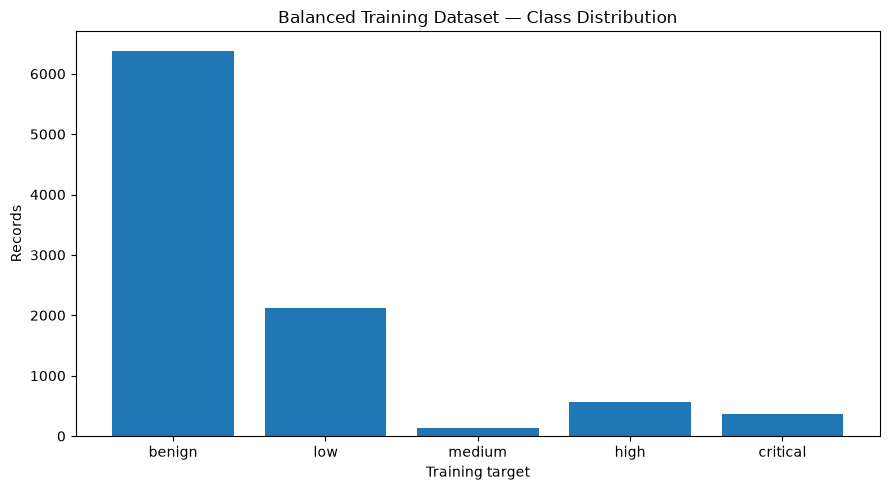

Saved: C:\Users\Lenovo\Desktop\DriftGuard\outputs\eda\figures\balanced_training_class_distribution.png


In [10]:
plt.figure(figsize=(9, 5))

plt.bar(
    training_class_distribution[
        "training_target"
    ],
    training_class_distribution["records"],
)

plt.title("Balanced Training Dataset — Class Distribution")
plt.xlabel("Training target")
plt.ylabel("Records")
plt.tight_layout()

training_class_figure_path = (
    EDA_FIGURES_DIR
    / "balanced_training_class_distribution.png"
)

plt.savefig(
    training_class_figure_path,
    dpi=EDA_SETTINGS["figure_dpi"],
    bbox_inches="tight",
)

plt.show()

print("Saved:", training_class_figure_path)

In [11]:
class_count_series = (
    balanced_training[
        "training_target"
    ]
    .value_counts()
)

non_zero_class_counts = (
    class_count_series[
        class_count_series > 0
    ]
)

largest_class = (
    non_zero_class_counts.idxmax()
)

smallest_class = (
    non_zero_class_counts.idxmin()
)

largest_class_count = int(
    non_zero_class_counts.max()
)

smallest_class_count = int(
    non_zero_class_counts.min()
)

maximum_imbalance_ratio = (
    largest_class_count
    / smallest_class_count
)

benign_count = int(
    class_count_series.get("benign", 0)
)

risky_count = int(
    class_count_series.reindex(
        [
            "low",
            "medium",
            "high",
            "critical",
        ],
        fill_value=0,
    ).sum()
)

strong_risk_count = int(
    class_count_series.reindex(
        [
            "medium",
            "high",
            "critical",
        ],
        fill_value=0,
    ).sum()
)

imbalance_report = pd.DataFrame(
    [
        {
            "metric": "largest_class",
            "value": largest_class,
        },
        {
            "metric": "largest_class_records",
            "value": largest_class_count,
        },
        {
            "metric": "smallest_class",
            "value": smallest_class,
        },
        {
            "metric": "smallest_class_records",
            "value": smallest_class_count,
        },
        {
            "metric": "maximum_imbalance_ratio",
            "value": round(
                maximum_imbalance_ratio,
                4,
            ),
        },
        {
            "metric": "benign_to_risky_ratio",
            "value": round(
                benign_count
                / max(risky_count, 1),
                4,
            ),
        },
        {
            "metric": "strong_risk_records",
            "value": strong_risk_count,
        },
    ]
)

display(imbalance_report)

imbalance_report.to_csv(
    EDA_TABLES_DIR
    / "training_imbalance_metrics.csv",
    index=False,
)

,metric,value
0,largest_class,benign
1,largest_class_records,6384
2,smallest_class,medium
3,smallest_class_records,140
4,maximum_imbalance_ratio,45.6
5,benign_to_risky_ratio,2.0
6,strong_risk_records,1064


In [12]:
temporal_partition_distribution = (
    balanced_training
    .groupby(
        [
            "temporal_partition",
            "training_target",
        ],
        as_index=False,
    )
    .size()
    .rename(
        columns={
            "size": "records",
        }
    )
)

temporal_partition_distribution[
    "percentage_within_partition"
] = (
    temporal_partition_distribution[
        "records"
    ]
    / temporal_partition_distribution.groupby(
        "temporal_partition"
    )["records"].transform("sum")
    * 100
)

display(
    temporal_partition_distribution.sort_values(
        [
            "temporal_partition",
            "records",
        ],
        ascending=[
            True,
            False,
        ],
    )
)

temporal_partition_distribution.to_csv(
    EDA_TABLES_DIR
    / "temporal_partition_class_distribution.csv",
    index=False,
)

,temporal_partition,training_target,records,percentage_within_partition
0,model_train,benign,5099,66.126313
3,model_train,low,1724,22.357671
2,model_train,high,471,6.108157
1,model_train,critical,294,3.812735
4,model_train,medium,123,1.595124
5,temporal_dev,benign,1285,68.900804
8,temporal_dev,low,404,21.662198
7,temporal_dev,high,95,5.093834
6,temporal_dev,critical,64,3.431635
9,temporal_dev,medium,17,0.911528


In [13]:
confidence_summary = (
    clean_manifest
    .groupby(
        [
            "dataset_split",
            "weak_label",
        ]
    )[
        "weak_label_confidence"
    ]
    .agg(
        records="count",
        mean="mean",
        median="median",
        minimum="min",
        maximum="max",
    )
    .reset_index()
)

display(confidence_summary)

confidence_summary.to_csv(
    EDA_TABLES_DIR
    / "weak_label_confidence_summary.csv",
    index=False,
)

,dataset_split,weak_label,records,mean,median,minimum,maximum
0,test,benign,46499,0.758237,0.720,0.72,0.92
1,test,critical,320,0.981687,0.980,0.98,0.99
2,test,high,180,0.955056,0.960,0.94,0.96
3,test,low,14816,0.760000,0.760,0.76,0.76
4,test,medium,84,0.910000,0.910,0.91,0.91
5,test,unlabeled,6850,0.000000,0.000,0.00,0.00
6,train,benign,70361,0.794209,0.720,0.72,0.92
7,train,critical,358,0.980866,0.980,0.98,0.99
8,train,high,566,0.951131,0.950,0.94,0.96
9,train,low,52965,0.760000,0.760,0.76,0.76


In [14]:
confidence_summary = (
    clean_manifest
    .groupby(
        [
            "dataset_split",
            "weak_label",
        ]
    )[
        "weak_label_confidence"
    ]
    .agg(
        records="count",
        mean="mean",
        median="median",
        minimum="min",
        maximum="max",
    )
    .reset_index()
)

display(confidence_summary)

confidence_summary.to_csv(
    EDA_TABLES_DIR
    / "weak_label_confidence_summary.csv",
    index=False,
)

,dataset_split,weak_label,records,mean,median,minimum,maximum
0,test,benign,46499,0.758237,0.720,0.72,0.92
1,test,critical,320,0.981687,0.980,0.98,0.99
2,test,high,180,0.955056,0.960,0.94,0.96
3,test,low,14816,0.760000,0.760,0.76,0.76
4,test,medium,84,0.910000,0.910,0.91,0.91
5,test,unlabeled,6850,0.000000,0.000,0.00,0.00
6,train,benign,70361,0.794209,0.720,0.72,0.92
7,train,critical,358,0.980866,0.980,0.98,0.99
8,train,high,566,0.951131,0.950,0.94,0.96
9,train,low,52965,0.760000,0.760,0.76,0.76


In [15]:
training_source_distribution = (
    balanced_training
    .groupby(
        [
            "training_label_source",
            "training_target",
        ],
        as_index=False,
    )
    .agg(
        records=("diff_id", "count"),
        mean_label_confidence=(
            "weak_label_confidence",
            "mean",
        ),
        mean_sample_weight=(
            "sample_weight",
            "mean",
        ),
    )
)

display(training_source_distribution)

training_source_distribution.to_csv(
    EDA_TABLES_DIR
    / "training_label_source_distribution.csv",
    index=False,
)

,training_label_source,training_target,records,mean_label_confidence,mean_sample_weight
0,high_confidence_core,benign,6384,0.920000,0.206497
1,high_confidence_core,critical,358,0.980866,9.808659
2,high_confidence_core,high,566,0.951131,9.493640
3,high_confidence_core,medium,140,0.910000,9.100000
4,provisional_low,low,2128,0.760000,1.255671


In [16]:
parser_mode_summary = (
    clean_manifest
    .groupby(
        [
            "dataset_split",
            "parser_mode",
        ],
        as_index=False,
    )
    .agg(
        records=("diff_id", "count"),
        repositories=("repository", "nunique"),
        commits=("commit_hash", "nunique"),
        field_paths=("field_path", "nunique"),
    )
)

parser_mode_summary[
    "percentage_within_split"
] = (
    parser_mode_summary["records"]
    / parser_mode_summary.groupby(
        "dataset_split"
    )["records"].transform("sum")
    * 100
)

display(parser_mode_summary)

parser_mode_summary.to_csv(
    EDA_TABLES_DIR
    / "parser_mode_summary.csv",
    index=False,
)

,dataset_split,parser_mode,records,repositories,commits,field_paths,percentage_within_split
0,test,line_fallback,8364,2,62,4242,12.165995
1,test,structured,60385,2,1243,22555,87.834005
2,train,line_fallback,25162,2,308,10379,17.535595
3,train,structured,118329,3,2574,40360,82.464405
4,validation,line_fallback,659,1,52,253,8.639224
5,validation,structured,6969,1,511,1529,91.360776


In [17]:
training_parser_label_matrix = pd.crosstab(
    balanced_training["training_target"],
    balanced_training["parser_mode"],
    margins=True,
)

display(training_parser_label_matrix)

training_parser_label_matrix.to_csv(
    EDA_TABLES_DIR
    / "training_parser_label_matrix.csv"
)

parser_mode,line_fallback,structured,All
training_target,,,
benign,0,6384,6384
critical,0,358,358
high,4,562,566
low,0,2128,2128
medium,0,140,140
All,4,9572,9576


In [18]:
configuration_type_distribution = (
    clean_manifest
    .groupby(
        [
            "dataset_split",
            "configuration_type",
        ],
        as_index=False,
    )
    .size()
    .rename(
        columns={
            "size": "records",
        }
    )
)

configuration_type_distribution[
    "percentage_within_split"
] = (
    configuration_type_distribution[
        "records"
    ]
    / configuration_type_distribution.groupby(
        "dataset_split"
    )["records"].transform("sum")
    * 100
)

display(
    configuration_type_distribution.sort_values(
        [
            "dataset_split",
            "records",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .groupby(
        "dataset_split",
        group_keys=False,
    )
    .head(
        EDA_SETTINGS[
            "top_n_configuration_types"
        ]
    )
)

configuration_type_distribution.to_csv(
    EDA_TABLES_DIR
    / "configuration_type_distribution.csv",
    index=False,
)

,dataset_split,configuration_type,records,percentage_within_split
7,test,terraform,34631,50.373096
9,test,yaml,10618,15.444588
5,test,kubernetes,8463,12.309997
4,test,json,7423,10.797248
0,test,ansible,4072,5.922995
6,test,nginx,1957,2.846587
3,test,helm,1420,2.065485
2,test,docker,108,0.157093
1,test,configuration,51,0.074183
8,test,toml,6,0.008727


In [19]:
configuration_type_distribution = (
    clean_manifest
    .groupby(
        [
            "dataset_split",
            "configuration_type",
        ],
        as_index=False,
    )
    .size()
    .rename(
        columns={
            "size": "records",
        }
    )
)

configuration_type_distribution[
    "percentage_within_split"
] = (
    configuration_type_distribution[
        "records"
    ]
    / configuration_type_distribution.groupby(
        "dataset_split"
    )["records"].transform("sum")
    * 100
)

display(
    configuration_type_distribution.sort_values(
        [
            "dataset_split",
            "records",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .groupby(
        "dataset_split",
        group_keys=False,
    )
    .head(
        EDA_SETTINGS[
            "top_n_configuration_types"
        ]
    )
)

configuration_type_distribution.to_csv(
    EDA_TABLES_DIR
    / "configuration_type_distribution.csv",
    index=False,
)

,dataset_split,configuration_type,records,percentage_within_split
7,test,terraform,34631,50.373096
9,test,yaml,10618,15.444588
5,test,kubernetes,8463,12.309997
4,test,json,7423,10.797248
0,test,ansible,4072,5.922995
6,test,nginx,1957,2.846587
3,test,helm,1420,2.065485
2,test,docker,108,0.157093
1,test,configuration,51,0.074183
8,test,toml,6,0.008727


In [20]:
operation_distribution = (
    clean_manifest
    .groupby(
        [
            "dataset_split",
            "operation",
        ],
        as_index=False,
    )
    .size()
    .rename(
        columns={
            "size": "records",
        }
    )
)

operation_distribution[
    "percentage_within_split"
] = (
    operation_distribution["records"]
    / operation_distribution.groupby(
        "dataset_split"
    )["records"].transform("sum")
    * 100
)

display(operation_distribution)

operation_distribution.to_csv(
    EDA_TABLES_DIR
    / "operation_distribution.csv",
    index=False,
)

,dataset_split,operation,records,percentage_within_split
0,test,added,33805,49.171624
1,test,deleted,29023,42.215887
2,test,modified,5921,8.612489
3,train,added,58863,41.022085
4,train,deleted,31332,21.835516
5,train,modified,53296,37.142399
6,validation,added,4615,60.500787
7,validation,deleted,2316,30.361825
8,validation,modified,697,9.137389


In [21]:
training_operation_matrix = pd.crosstab(
    balanced_training["training_target"],
    balanced_training["operation"],
    margins=True,
)

display(training_operation_matrix)

training_operation_matrix.to_csv(
    EDA_TABLES_DIR
    / "training_operation_matrix.csv"
)

operation,added,deleted,modified,All
training_target,,,,
benign,2178,1886,2320,6384
critical,65,289,4,358
high,304,91,171,566
low,747,665,716,2128
medium,1,139,0,140
All,3295,3070,3211,9576


In [23]:
top_field_paths = (
    clean_manifest[
        "field_path"
    ]
    .value_counts()
    .head(
        EDA_SETTINGS[
            "top_n_field_paths"
        ]
    )
    .rename_axis("field_path")
    .reset_index(name="records")
)

display(top_field_paths)

top_field_paths.to_csv(
    EDA_TABLES_DIR / "top_field_paths.csv",
    index=False,
)

,field_path,records
0,$.metadata.name,682
1,$.spec.template.spec.containers[0].image,655
2,$.instructions.FROM[0],466
3,$.metadata.labels.app.kubernetes.io/version,399
4,$.documents[0].spec.template.spec.containers[0...,388
5,$.spec.template.metadata.labels.app.kubernetes...,287
6,$.dependencies[1].version,270
7,$.dependencies[7].version,259
8,$.dependencies[8].version,244
9,$.dependencies[13].version,228


In [24]:
def calculate_field_path_depth(field_path):
    if pd.isna(field_path):
        return 0

    text = str(field_path)

    dot_segments = text.count(".")
    array_segments = text.count("[")

    return dot_segments + array_segments


clean_manifest["field_path_depth"] = (
    clean_manifest["field_path"]
    .apply(calculate_field_path_depth)
)

balanced_training["field_path_depth"] = (
    balanced_training["field_path"]
    .apply(calculate_field_path_depth)
)

field_depth_summary = (
    balanced_training
    .groupby("training_target")[
        "field_path_depth"
    ]
    .agg(
        records="count",
        mean="mean",
        median="median",
        minimum="min",
        maximum="max",
    )
    .reset_index()
)

display(field_depth_summary)

field_depth_summary.to_csv(
    EDA_TABLES_DIR
    / "training_field_path_depth_summary.csv",
    index=False,
)

,training_target,records,mean,median,minimum,maximum
0,benign,6384,5.828947,4.0,1,24
1,critical,358,7.980447,5.0,1,23
2,high,566,7.636042,7.0,1,20
3,low,2128,5.641917,5.0,1,24
4,medium,140,10.564286,10.0,8,22


In [25]:
def parse_json_list(value):
    if isinstance(value, list):
        return value

    if pd.isna(value):
        return []

    text = str(value).strip()

    if not text:
        return []

    try:
        parsed_value = json.loads(text)

        if isinstance(parsed_value, list):
            return parsed_value

        return [parsed_value]

    except Exception:
        return [
            item.strip()
            for item in text.split(",")
            if item.strip()
        ]


clean_manifest[
    "parsed_sensitive_terms"
] = (
    clean_manifest[
        "sensitive_terms"
    ]
    .apply(parse_json_list)
)

clean_manifest[
    "parsed_matched_rule_ids"
] = (
    clean_manifest[
        "matched_rule_ids"
    ]
    .apply(parse_json_list)
)

print("JSON list columns parsed.")

JSON list columns parsed.


In [27]:
sensitive_term_counts = Counter()

for terms in clean_manifest[
    "parsed_sensitive_terms"
]:
    sensitive_term_counts.update(
        str(term)
        for term in terms
        if str(term).strip()
    )

sensitive_term_distribution = pd.DataFrame(
    [
        {
            "sensitive_term": term,
            "records": count,
        }
        for term, count
        in sensitive_term_counts.most_common(
            EDA_SETTINGS[
                "top_n_sensitive_terms"
            ]
        )
    ]
)

display(sensitive_term_distribution)

sensitive_term_distribution.to_csv(
    EDA_TABLES_DIR
    / "top_sensitive_terms.csv",
    index=False,
)

,sensitive_term,records
0,port,21663
1,https,15509
2,resources,8755
3,secret,7252
4,auth,7148
5,tls,6406
6,ingress,4505
7,oauth,3115
8,allow,2669
9,memory,2191


In [28]:
rule_distribution = (
    clean_manifest[
        clean_manifest[
            "primary_rule_id"
        ].notna()
    ]
    .groupby(
        [
            "primary_rule_id",
            "weak_label",
        ],
        as_index=False,
    )
    .agg(
        records=("diff_id", "count"),
        repositories=("repository", "nunique"),
        commits=("commit_hash", "nunique"),
        mean_confidence=(
            "weak_label_confidence",
            "mean",
        ),
    )
    .sort_values(
        "records",
        ascending=False,
    )
)

display(
    rule_distribution.head(
        EDA_SETTINGS["top_n_rules"]
    )
)

rule_distribution.to_csv(
    EDA_TABLES_DIR
    / "security_rule_distribution.csv",
    index=False,
)

,primary_rule_id,weak_label,records,repositories,commits,mean_confidence
9,UNCLASSIFIED_SENSITIVE_FIELD_CHANGE,low,69865,6,2164,0.760000
0,AUTH_REMOVED,critical,529,5,85,0.980000
4,OPEN_PORT_EXPOSURE,high,358,6,133,0.960000
7,RESOURCE_LIMIT_REMOVED,medium,249,4,53,0.910000
2,INSECURE_PROTOCOL,high,236,5,139,0.950000
6,PERMISSIVE_ACL,high,209,4,36,0.940000
8,TLS_DISABLED,critical,78,4,26,0.981538
3,OPEN_PORT_EXPOSURE,critical,46,3,27,0.990000
1,DEFAULT_CREDENTIALS,critical,40,5,27,0.990000
5,PERMISSIVE_ACL,critical,11,3,11,0.980000


In [29]:
for dataframe in [
    clean_manifest,
    balanced_training,
]:
    dataframe["old_value_length_eda"] = (
        dataframe["old_value"]
        .fillna("")
        .astype(str)
        .str.len()
    )

    dataframe["new_value_length_eda"] = (
        dataframe["new_value"]
        .fillna("")
        .astype(str)
        .str.len()
    )

    dataframe["value_length_change_eda"] = (
        dataframe["new_value_length_eda"]
        - dataframe["old_value_length_eda"]
    )


value_length_summary = (
    balanced_training
    .groupby("training_target")
    .agg(
        records=("diff_id", "count"),
        mean_old_length=(
            "old_value_length_eda",
            "mean",
        ),
        median_old_length=(
            "old_value_length_eda",
            "median",
        ),
        mean_new_length=(
            "new_value_length_eda",
            "mean",
        ),
        median_new_length=(
            "new_value_length_eda",
            "median",
        ),
        mean_length_change=(
            "value_length_change_eda",
            "mean",
        ),
    )
    .reset_index()
)

display(value_length_summary)

value_length_summary.to_csv(
    EDA_TABLES_DIR
    / "training_value_length_summary.csv",
    index=False,
)

,training_target,records,mean_old_length,median_old_length,mean_new_length,median_new_length,mean_length_change
0,benign,6384,27.119361,7.0,28.723214,9.0,1.603853
1,critical,358,19.899441,6.0,4.083799,0.0,-15.815642
2,high,566,39.333922,0.0,85.270318,41.0,45.936396
3,low,2128,51.022556,6.0,53.246711,7.0,2.224154
4,medium,140,8.664286,5.0,0.007143,0.0,-8.657143


In [30]:
commit_level_summary = (
    clean_manifest
    .groupby(
        [
            "dataset_split",
            "repository",
            "commit_hash",
        ],
        as_index=False,
    )
    .agg(
        commit_author_datetime=(
            "commit_author_datetime",
            "min",
        ),
        diff_records=("diff_id", "count"),
        source_file_changes=(
            "source_record_id",
            "nunique",
        ),
        files_changed=("file_path", "nunique"),
        field_paths=("field_path", "nunique"),
        sensitive_records=(
            "sensitive_term_count",
            lambda values: int(
                (
                    pd.to_numeric(
                        values,
                        errors="coerce",
                    ).fillna(0)
                    > 0
                ).sum()
            ),
        ),
    )
)

commit_level_statistics = (
    commit_level_summary
    .groupby(
        [
            "dataset_split",
            "repository",
        ]
    )
    .agg(
        commits=("commit_hash", "count"),
        mean_diffs_per_commit=(
            "diff_records",
            "mean",
        ),
        median_diffs_per_commit=(
            "diff_records",
            "median",
        ),
        maximum_diffs_per_commit=(
            "diff_records",
            "max",
        ),
        mean_files_per_commit=(
            "files_changed",
            "mean",
        ),
        mean_sensitive_records=(
            "sensitive_records",
            "mean",
        ),
    )
    .reset_index()
)

display(commit_level_statistics)

commit_level_statistics.to_csv(
    EDA_TABLES_DIR
    / "commit_level_statistics.csv",
    index=False,
)

,dataset_split,repository,commits,mean_diffs_per_commit,median_diffs_per_commit,maximum_diffs_per_commit,mean_files_per_commit,mean_sensitive_records
0,test,ansible_examples,195,31.482051,5.0,740,3.666667,3.958974
1,test,terraform_eks_blueprints,1057,59.233680,5.0,8132,4.941343,13.755913
2,train,kube_prometheus,1216,62.759046,6.0,2364,3.289474,22.833882
3,train,microservices_demo,1150,49.604348,2.0,1887,2.412174,20.440000
4,train,terraform_aws_vpc,276,36.706522,5.0,1919,2.590580,8.942029
5,validation,kubernetes_examples,534,14.284644,5.0,207,2.713483,4.028090


In [31]:
valid_temporal_records = (
    commit_level_summary[
        commit_level_summary[
            "commit_author_datetime"
        ].notna()
    ]
    .copy()
)

valid_temporal_records[
    "commit_month"
] = (
    valid_temporal_records[
        "commit_author_datetime"
    ]
    .dt.to_period("M")
    .astype(str)
)

monthly_activity = (
    valid_temporal_records
    .groupby(
        [
            "dataset_split",
            "commit_month",
        ],
        as_index=False,
    )
    .agg(
        commits=("commit_hash", "nunique"),
        diff_records=("diff_records", "sum"),
        files_changed=("files_changed", "sum"),
    )
)

display(monthly_activity.tail(30))

monthly_activity.to_csv(
    EDA_TABLES_DIR
    / "monthly_drift_activity.csv",
    index=False,
)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11468\1163743972.py:16: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .dt.to_period("M")


,dataset_split,commit_month,commits,diff_records,files_changed
279,validation,2018-10,4,7,6
280,validation,2018-11,2,3,2
281,validation,2019-01,2,2,2
282,validation,2019-03,1,34,2
283,validation,2019-05,2,12,2
284,validation,2019-06,1,1,1
285,validation,2019-09,1,1,1
286,validation,2019-11,1,1,1
287,validation,2020-03,3,27,8
288,validation,2020-08,1,4,1


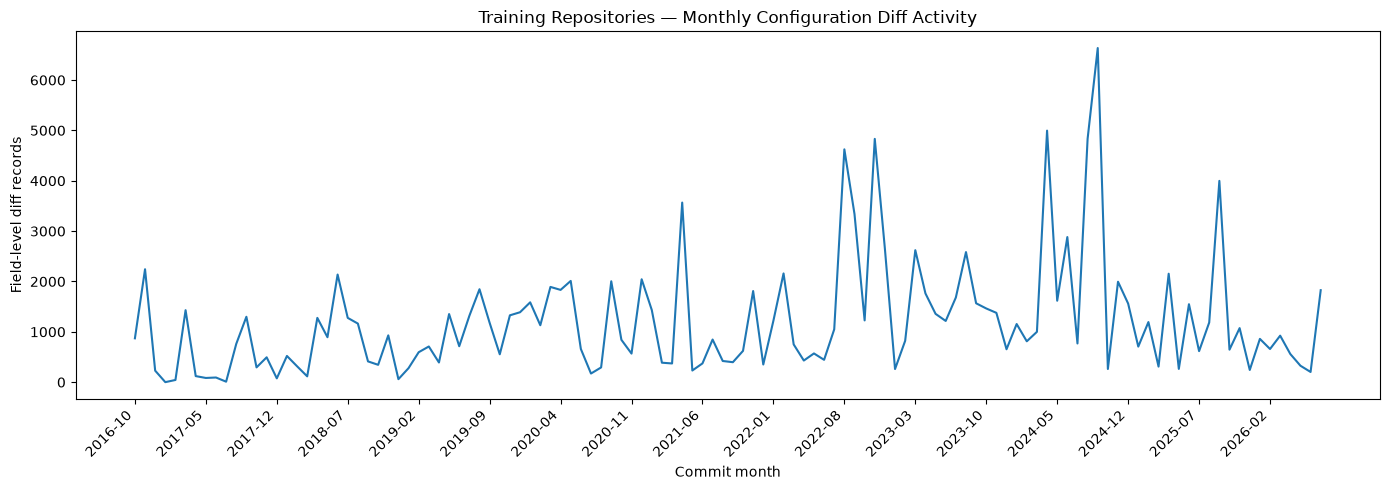

Saved: C:\Users\Lenovo\Desktop\DriftGuard\outputs\eda\figures\training_monthly_drift_activity.png


In [32]:
training_monthly_activity = (
    monthly_activity[
        monthly_activity[
            "dataset_split"
        ].eq("train")
    ]
    .sort_values("commit_month")
    .copy()
)

if not training_monthly_activity.empty:
    plt.figure(figsize=(14, 5))

    plt.plot(
        training_monthly_activity[
            "commit_month"
        ],
        training_monthly_activity[
            "diff_records"
        ],
    )

    plt.title("Training Repositories — Monthly Configuration Diff Activity")
    plt.xlabel("Commit month")
    plt.ylabel("Field-level diff records")

    tick_step = max(
        1,
        len(training_monthly_activity) // 15,
    )

    plt.xticks(
        training_monthly_activity[
            "commit_month"
        ][::tick_step],
        rotation=45,
        ha="right",
    )

    plt.tight_layout()

    temporal_figure_path = (
        EDA_FIGURES_DIR
        / "training_monthly_drift_activity.png"
    )

    plt.savefig(
        temporal_figure_path,
        dpi=EDA_SETTINGS["figure_dpi"],
        bbox_inches="tight",
    )

    plt.show()

    print("Saved:", temporal_figure_path)

else:
    print("No valid training timestamps available.")

In [33]:
holdout_structural_summary = []

for split_name in [
    "train",
    "validation",
    "test",
]:
    split_data = clean_manifest[
        clean_manifest[
            "dataset_split"
        ].eq(split_name)
    ]

    holdout_structural_summary.append(
        {
            "dataset_split": split_name,
            "records": len(split_data),
            "repositories": split_data[
                "repository"
            ].nunique(),
            "commits": split_data[
                "commit_hash"
            ].nunique(),
            "configuration_types": split_data[
                "configuration_type"
            ].nunique(),
            "field_paths": split_data[
                "field_path"
            ].nunique(),
            "structured_percentage": (
                split_data[
                    "parser_mode"
                ].eq("structured").mean()
                * 100
            ),
            "fallback_percentage": (
                split_data[
                    "parser_mode"
                ].eq("line_fallback").mean()
                * 100
            ),
            "added_percentage": (
                split_data[
                    "operation"
                ].eq("added").mean()
                * 100
            ),
            "deleted_percentage": (
                split_data[
                    "operation"
                ].eq("deleted").mean()
                * 100
            ),
            "modified_percentage": (
                split_data[
                    "operation"
                ].eq("modified").mean()
                * 100
            ),
        }
    )

holdout_structural_summary = pd.DataFrame(
    holdout_structural_summary
)

display(holdout_structural_summary)

holdout_structural_summary.to_csv(
    EDA_TABLES_DIR
    / "holdout_structural_summary.csv",
    index=False,
)

,dataset_split,records,repositories,commits,configuration_types,field_paths,structured_percentage,fallback_percentage,added_percentage,deleted_percentage,modified_percentage
0,train,143491,3,2642,10,50739,82.464405,17.535595,41.022085,21.835516,37.142399
1,validation,7628,1,534,5,1782,91.360776,8.639224,60.500787,30.361825,9.137389
2,test,68749,2,1252,10,26797,87.834005,12.165995,49.171624,42.215887,8.612489


In [34]:
def categorical_distribution(
    series,
    categories,
):
    counts = (
        series
        .fillna("<MISSING>")
        .astype(str)
        .value_counts()
        .reindex(
            categories,
            fill_value=0,
        )
        .astype(float)
        .to_numpy()
    )

    total = counts.sum()

    if total == 0:
        return np.zeros(
            len(categories),
            dtype=float,
        )

    return counts / total


def jensen_shannon_divergence(
    first_distribution,
    second_distribution,
):
    first_distribution = np.asarray(
        first_distribution,
        dtype=float,
    )

    second_distribution = np.asarray(
        second_distribution,
        dtype=float,
    )

    midpoint = (
        first_distribution
        + second_distribution
    ) / 2.0

    def kl_divergence(first, second):
        valid = (
            first > 0
        ) & (
            second > 0
        )

        return float(
            np.sum(
                first[valid]
                * np.log2(
                    first[valid]
                    / second[valid]
                )
            )
        )

    return 0.5 * (
        kl_divergence(
            first_distribution,
            midpoint,
        )
        + kl_divergence(
            second_distribution,
            midpoint,
        )
    )


print("Distribution-shift helpers loaded.")

Distribution-shift helpers loaded.


In [35]:
SHIFT_COLUMNS = [
    "configuration_type",
    "operation",
    "parser_mode",
]

clean_train_natural = (
    clean_manifest[
        clean_manifest[
            "dataset_split"
        ].eq("train")
    ]
)

distribution_shift_records = []

for column in SHIFT_COLUMNS:
    categories = sorted(
        set(
            clean_manifest[column]
            .fillna("<MISSING>")
            .astype(str)
            .unique()
        )
    )

    train_distribution = (
        categorical_distribution(
            clean_train_natural[column],
            categories,
        )
    )

    for comparison_split in [
        "validation",
        "test",
    ]:
        comparison_data = (
            clean_manifest[
                clean_manifest[
                    "dataset_split"
                ].eq(comparison_split)
            ]
        )

        comparison_distribution = (
            categorical_distribution(
                comparison_data[column],
                categories,
            )
        )

        divergence = (
            jensen_shannon_divergence(
                train_distribution,
                comparison_distribution,
            )
        )

        distribution_shift_records.append(
            {
                "feature": column,
                "comparison": (
                    f"train_vs_{comparison_split}"
                ),
                "jensen_shannon_divergence":
                    divergence,
            }
        )

distribution_shift_report = pd.DataFrame(
    distribution_shift_records
)

display(distribution_shift_report)

distribution_shift_report.to_csv(
    EDA_TABLES_DIR
    / "structural_distribution_shift.csv",
    index=False,
)

,feature,comparison,jensen_shannon_divergence
0,configuration_type,train_vs_validation,0.141616
1,configuration_type,train_vs_test,0.325009
2,operation,train_vs_validation,0.084147
3,operation,train_vs_test,0.095606
4,parser_mode,train_vs_validation,0.012769
5,parser_mode,train_vs_test,0.004131


In [37]:
category_shift_records = []

for column in SHIFT_COLUMNS:
    categories = sorted(
        set(
            clean_manifest[column]
            .fillna("<MISSING>")
            .astype(str)
            .unique()
        )
    )

    train_distribution = (
        categorical_distribution(
            clean_train_natural[column],
            categories,
        )
    )

    for comparison_split in [
        "validation",
        "test",
    ]:
        comparison_data = clean_manifest[
            clean_manifest[
                "dataset_split"
            ].eq(comparison_split)
        ]

        comparison_distribution = (
            categorical_distribution(
                comparison_data[column],
                categories,
            )
        )

        for category, train_share, comparison_share in zip(
            categories,
            train_distribution,
            comparison_distribution,
        ):
            category_shift_records.append(
                {
                    "feature": column,
                    "category": category,
                    "comparison_split":
                        comparison_split,
                    "train_percentage":
                        train_share * 100,
                    "comparison_percentage":
                        comparison_share * 100,
                    "absolute_shift_percentage_points":
                        abs(
                            comparison_share
                            - train_share
                        )
                        * 100,
                }
            )

category_shift_report = (
    pd.DataFrame(
        category_shift_records
    )
    .sort_values(
        "absolute_shift_percentage_points",
        ascending=False,
    )
)

display(category_shift_report.head(30))

category_shift_report.to_csv(
    EDA_TABLES_DIR
    / "largest_structural_category_shifts.csv",
    index=False,
)

,feature,category,comparison_split,train_percentage,comparison_percentage,absolute_shift_percentage_points
21,configuration_type,terraform,test,6.896600,50.373096,43.476497
23,configuration_type,yaml,test,44.765177,15.444588,29.320589
29,operation,modified,test,37.142399,8.612489,28.529910
26,operation,modified,validation,37.142399,9.137389,28.005011
17,configuration_type,json,test,38.613572,10.797248,27.816324
28,operation,deleted,test,21.835516,42.215887,20.380371
24,operation,added,validation,41.022085,60.500787,19.478702
11,configuration_type,yaml,validation,44.765177,63.266911,18.501734
5,configuration_type,json,validation,38.613572,25.235973,13.377599
30,parser_mode,line_fallback,validation,17.535595,8.639224,8.896371


In [38]:
eda_integrity_checks = {
    "Clean manifest loaded":
        len(clean_manifest) == 219_868,

    "Balanced training records loaded":
        len(balanced_training) == 9_576,

    "Model-training records loaded":
        len(model_training) == 7_711,

    "Temporal-development records loaded":
        len(temporal_development) == 1_865,

    "Validation records loaded":
        len(validation_review) == 7_628,

    "Test records loaded":
        len(test_review) == 68_749,

    "Balanced training contains five classes":
        balanced_training[
            "training_target"
        ].nunique() == 5,

    "Training contains no validation repositories":
        set(
            balanced_training[
                "repository"
            ].unique()
        ).isdisjoint(
            set(
                validation_review[
                    "repository"
                ].unique()
            )
        ),

    "Training contains no test repositories":
        set(
            balanced_training[
                "repository"
            ].unique()
        ).isdisjoint(
            set(
                test_review[
                    "repository"
                ].unique()
            )
        ),

    "No temporal commit overlap":
        set(
            zip(
                model_training[
                    "repository"
                ],
                model_training[
                    "commit_hash"
                ],
            )
        ).isdisjoint(
            set(
                zip(
                    temporal_development[
                        "repository"
                    ],
                    temporal_development[
                        "commit_hash"
                    ],
                )
            )
        ),

    "No missing training targets":
        balanced_training[
            "training_target"
        ].notna().all(),

    "All sample weights are positive":
        (
            balanced_training[
                "sample_weight"
            ] > 0
        ).all(),

    "Structural shift report generated":
        not distribution_shift_report.empty,

    "EDA tables directory exists":
        EDA_TABLES_DIR.exists(),

    "EDA figures directory exists":
        EDA_FIGURES_DIR.exists(),
}

print("EDA integrity checks:\n")

for check_name, passed in (
    eda_integrity_checks.items()
):
    print(
        f"{'PASSED' if passed else 'FAILED':<8}"
        f" | {check_name}"
    )

failed_eda_checks = [
    check_name
    for check_name, passed
    in eda_integrity_checks.items()
    if not bool(passed)
]

print("\nFailed checks:", len(failed_eda_checks))

EDA integrity checks:

PASSED   | Clean manifest loaded
PASSED   | Balanced training records loaded
PASSED   | Model-training records loaded
PASSED   | Temporal-development records loaded
PASSED   | Validation records loaded
PASSED   | Test records loaded
PASSED   | Balanced training contains five classes
PASSED   | Training contains no validation repositories
PASSED   | Training contains no test repositories
PASSED   | No temporal commit overlap
PASSED   | No missing training targets
PASSED   | All sample weights are positive
PASSED   | Structural shift report generated
PASSED   | EDA tables directory exists
PASSED   | EDA figures directory exists

Failed checks: 0


In [39]:
maximum_structural_shift = float(
    distribution_shift_report[
        "jensen_shannon_divergence"
    ].max()
)

maximum_shift_row = (
    distribution_shift_report
    .sort_values(
        "jensen_shannon_divergence",
        ascending=False,
    )
    .iloc[0]
)

eda_summary = {
    "generated_at_utc": datetime.now(
        timezone.utc
    ).isoformat(),

    "clean_records": int(
        len(clean_manifest)
    ),

    "balanced_training_records": int(
        len(balanced_training)
    ),

    "model_training_records": int(
        len(model_training)
    ),

    "temporal_development_records": int(
        len(temporal_development)
    ),

    "validation_records": int(
        len(validation_review)
    ),

    "test_records": int(
        len(test_review)
    ),

    "training_class_distribution": {
        str(label): int(count)
        for label, count
        in balanced_training[
            "training_target"
        ].value_counts().items()
    },

    "largest_training_class":
        largest_class,

    "smallest_training_class":
        smallest_class,

    "maximum_class_imbalance_ratio":
        float(maximum_imbalance_ratio),

    "strong_risk_records":
        int(strong_risk_count),

    "maximum_structural_shift": {
        "feature": str(
            maximum_shift_row["feature"]
        ),
        "comparison": str(
            maximum_shift_row["comparison"]
        ),
        "jensen_shannon_divergence":
            maximum_structural_shift,
    },

    "failed_eda_checks":
        failed_eda_checks,

    "all_eda_checks_passed":
        len(failed_eda_checks) == 0,
}

eda_summary_path = (
    EDA_OUTPUT_DIR
    / "exploratory_data_analysis_summary.json"
)

with eda_summary_path.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        eda_summary,
        file,
        indent=2,
    )

print("Saved EDA summary:", eda_summary_path)

Saved EDA summary: C:\Users\Lenovo\Desktop\DriftGuard\outputs\eda\exploratory_data_analysis_summary.json


In [40]:
structured_record_count = int(
    clean_manifest[
        "parser_mode"
    ].eq("structured").sum()
)

fallback_record_count = int(
    clean_manifest[
        "parser_mode"
    ].eq("line_fallback").sum()
)

structured_percentage = (
    structured_record_count
    / len(clean_manifest)
    * 100
)

fallback_percentage = (
    fallback_record_count
    / len(clean_manifest)
    * 100
)

print("=" * 72)
print("NOTEBOOK 06 — REQUIRED RESULTS")
print("=" * 72)

print("\n1. DATASET INVENTORY")
print("-" * 72)

print(
    "Leakage-safe records       :",
    f"{len(clean_manifest):,}",
)

print(
    "Balanced training records  :",
    f"{len(balanced_training):,}",
)

print(
    "Model-training records     :",
    f"{len(model_training):,}",
)

print(
    "Temporal-development records:",
    f"{len(temporal_development):,}",
)

print(
    "Validation records         :",
    f"{len(validation_review):,}",
)

print(
    "Test records               :",
    f"{len(test_review):,}",
)

print("\n2. TRAINING CLASS DISTRIBUTION")
print("-" * 72)

display(training_class_distribution)

print(
    "Largest-to-smallest imbalance ratio:",
    f"{maximum_imbalance_ratio:.2f}",
)

print(
    "Medium + high + critical records    :",
    f"{strong_risk_count:,}",
)

print("\n3. PARSER QUALITY")
print("-" * 72)

print(
    "Structured records:",
    f"{structured_record_count:,}",
    f"({structured_percentage:.2f}%)",
)

print(
    "Fallback records  :",
    f"{fallback_record_count:,}",
    f"({fallback_percentage:.2f}%)",
)

print("\n4. TOP SECURITY RULES")
print("-" * 72)

display(
    rule_distribution[
        [
            "primary_rule_id",
            "weak_label",
            "records",
            "mean_confidence",
        ]
    ].head(10)
)

print("\n5. STRUCTURAL DISTRIBUTION SHIFT")
print("-" * 72)

display(distribution_shift_report)

print(
    "Maximum Jensen-Shannon divergence:",
    f"{maximum_structural_shift:.4f}",
)

print(
    "Maximum-shift feature:",
    maximum_shift_row["feature"],
)

print(
    "Maximum-shift comparison:",
    maximum_shift_row["comparison"],
)

print("\n6. FAILED EDA CHECKS")
print("-" * 72)

if failed_eda_checks:
    for index, check_name in enumerate(
        failed_eda_checks,
        start=1,
    ):
        print(f"{index}. {check_name}")
else:
    print("No failed EDA checks.")
    print("All EDA integrity checks passed.")

print("\n" + "=" * 72)
print("REQUIRED RESULTS GENERATED")
print("=" * 72)

NOTEBOOK 06 — REQUIRED RESULTS

1. DATASET INVENTORY
------------------------------------------------------------------------
Leakage-safe records       : 219,868
Balanced training records  : 9,576
Model-training records     : 7,711
Temporal-development records: 1,865
Validation records         : 7,628
Test records               : 68,749

2. TRAINING CLASS DISTRIBUTION
------------------------------------------------------------------------


,training_target,records,percentage
0,benign,6384,66.666667
1,low,2128,22.222222
2,medium,140,1.461988
3,high,566,5.910610
4,critical,358,3.738513


Largest-to-smallest imbalance ratio: 45.60
Medium + high + critical records    : 1,064

3. PARSER QUALITY
------------------------------------------------------------------------
Structured records: 185,683 (84.45%)
Fallback records  : 34,185 (15.55%)

4. TOP SECURITY RULES
------------------------------------------------------------------------


,primary_rule_id,weak_label,records,mean_confidence
9,UNCLASSIFIED_SENSITIVE_FIELD_CHANGE,low,69865,0.760000
0,AUTH_REMOVED,critical,529,0.980000
4,OPEN_PORT_EXPOSURE,high,358,0.960000
7,RESOURCE_LIMIT_REMOVED,medium,249,0.910000
2,INSECURE_PROTOCOL,high,236,0.950000
6,PERMISSIVE_ACL,high,209,0.940000
8,TLS_DISABLED,critical,78,0.981538
3,OPEN_PORT_EXPOSURE,critical,46,0.990000
1,DEFAULT_CREDENTIALS,critical,40,0.990000
5,PERMISSIVE_ACL,critical,11,0.980000



5. STRUCTURAL DISTRIBUTION SHIFT
------------------------------------------------------------------------


,feature,comparison,jensen_shannon_divergence
0,configuration_type,train_vs_validation,0.141616
1,configuration_type,train_vs_test,0.325009
2,operation,train_vs_validation,0.084147
3,operation,train_vs_test,0.095606
4,parser_mode,train_vs_validation,0.012769
5,parser_mode,train_vs_test,0.004131


Maximum Jensen-Shannon divergence: 0.3250
Maximum-shift feature: configuration_type
Maximum-shift comparison: train_vs_test

6. FAILED EDA CHECKS
------------------------------------------------------------------------
No failed EDA checks.
All EDA integrity checks passed.

REQUIRED RESULTS GENERATED


In [41]:
print("=" * 72)
print("NOTEBOOK 06 COMPLETED")
print("=" * 72)

print(
    "Leakage-safe records analyzed:",
    f"{len(clean_manifest):,}",
)

print(
    "Balanced training records    :",
    f"{len(balanced_training):,}",
)

print(
    "Training classes             :",
    balanced_training[
        "training_target"
    ].nunique(),
)

print(
    "Structured parser percentage:",
    f"{structured_percentage:.2f}%",
)

print(
    "Maximum class imbalance ratio:",
    f"{maximum_imbalance_ratio:.2f}",
)

print(
    "Strong-risk training records :",
    f"{strong_risk_count:,}",
)

print(
    "EDA tables generated         :",
    len(
        list(
            EDA_TABLES_DIR.glob("*.csv")
        )
    ),
)

print(
    "EDA figures generated        :",
    len(
        list(
            EDA_FIGURES_DIR.glob("*.png")
        )
    ),
)

print("\nImportant:")
print("- Medium and critical classes remain comparatively small.")
print("- Macro F1 must remain the primary baseline metric.")
print("- Accuracy alone will be misleading for this dataset.")
print("- Class and sample weights should be used during training.")
print("- Test weak-label patterns must not be used for threshold tuning.")
print("- Repository-disjoint and temporal evaluation remain mandatory.")

print("\nNext notebook:")
print("07_train_baseline_models.ipynb")

NOTEBOOK 06 COMPLETED
Leakage-safe records analyzed: 219,868
Balanced training records    : 9,576
Training classes             : 5
Structured parser percentage: 84.45%
Maximum class imbalance ratio: 45.60
Strong-risk training records : 1,064
EDA tables generated         : 23
EDA figures generated        : 3

Important:
- Medium and critical classes remain comparatively small.
- Macro F1 must remain the primary baseline metric.
- Accuracy alone will be misleading for this dataset.
- Class and sample weights should be used during training.
- Test weak-label patterns must not be used for threshold tuning.
- Repository-disjoint and temporal evaluation remain mandatory.

Next notebook:
07_train_baseline_models.ipynb
